In [5]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np

import string
import windrose
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from metpy.calc import wind_direction,wind_speed
from metpy.units import units

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [6]:
def get_df_from_nc(file, var, loc_sel=None):
    ds = xr.open_dataset(file)
    time_dim = ds[var].dims[0]
    df = pd.DataFrame(ds[var].values, columns=ds.location, index=pd.to_datetime(ds[time_dim],utc=True))
    if loc_sel is None:
        return df
    else:
        return df[loc_sel]

def get_mean_timeframe(str_from, str_to):
    def add_to_output(df_in, mask, col_name):
        s_cnt = df_in.where(mask)[dt_from:dt_to].count()
        s_mean = df_in.where(mask)[dt_from:dt_to].mean()
        s_mean[s_cnt<12]=np.nan
        s_mean.name = col_name
        return pd.merge(df_out, s_mean, left_on='loc', right_index=True, how='left')
        
    dt_from = pd.to_datetime(str_from, utc=True)
    dt_to   = pd.to_datetime(str_to, utc=True)

    df_out = df_loc.copy()
    
    df_out = add_to_output(df_temp,   temp_mask, 'temp_o')
    df_out = add_to_output(df_i_temp, temp_mask, 'temp_i')

    df_out = add_to_output(df_u,   wind_mask, 'u_o')
    df_out = add_to_output(df_v,   wind_mask, 'v_o')
    df_out = add_to_output(df_i_u, wind_mask, 'u_i')
    df_out = add_to_output(df_i_v, wind_mask, 'v_i')
    
    return df_out

def get_wind_for_loc(file, suf, loc_str):
    """
    Reads u and v wind components from a file for given location, calculates wind speed and direction and returns as dataframe.
    :param file: .nc filename to read from
    :param suf: suffix for variable name (e.g. '_avg' for 30min avg wind)
    :param loc_str: location string (e.g. 'T275')
    :return:
    """
    df_u = get_df_from_nc(data_dir + file, f'u{suf}', [loc_str])
    df_v = get_df_from_nc(data_dir + file, f'v{suf}', [loc_str])

    df_out = pd.DataFrame(index=df_u.index)
    df_out['ws'] = wind_speed(df_u[loc_str].values * units('m/s'), df_v[loc_str].values * units('m/s'))
    df_out['wd'] = wind_direction(df_u[loc_str].values * units('m/s'), df_v[loc_str].values * units('m/s'))
    return df_out

## Script settings

In [7]:
loc_temp = ['D316','A309','D305','T303','D293','D285','D281','T275','D269','A267','A267R','A267L','A260','A255','STHE']
loc_wind = ['D316','A309','T303', 'D293', 'D281','T275','D269','A267','A267L','A267R','A260','A255', 'STHE' ]

use_avg_wind = True
loc_windrose = 'T275'

## Read data

The data used for this figure is available at Zenodo:

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19568035.svg)](https://doi.org/10.5281/zenodo.19568035)

In [8]:
# get outline of Hintereisferner (HEF)
rgi = gpd.read_file('../data_in/Glacier_Outlines_v370_2030_smoothed.geojson')
rgi_hef = rgi.loc[rgi['rgi_id'] == 'RGI60-11.00897']

In [9]:
file_obs  = f'HEFEX2__Obs_AWS_L1__1h_avg30min_20230816-20230910.nc'
file_icon = f'HEFEX2__ICON_v370_2030_aws_locations__1h_avg30min_20230815-20230914.nc'

In [10]:
# get locations with coords
ds = xr.open_dataset(data_dir + file_obs)

df_loc = pd.DataFrame()
df_loc['loc'] = ds.location.values
df_loc['lon'] = ds.lon.values
df_loc['lat'] = ds.lat.values

In [11]:
# get temp data
df_temp   = get_df_from_nc(data_dir + file_obs,  't_2m')
df_i_temp = get_df_from_nc(data_dir + file_icon, 't_5m') - 273.15

# get wind vectors (surface)
if use_avg_wind: 
    avg_suf = '_avg'  # get 30min avg wind
else: 
    avg_suf = ''      # inst wind at full hour
    
df_u = get_df_from_nc(data_dir + file_obs, f'u{avg_suf}')
df_v = get_df_from_nc(data_dir + file_obs, f'v{avg_suf}')

df_i_u = get_df_from_nc(data_dir + file_icon, f'u_5m{avg_suf}')
df_i_v = get_df_from_nc(data_dir + file_icon, f'v_5m{avg_suf}')

# calculate wind speed and direction for defined windrose location
df_wind_o = get_wind_for_loc(file_obs, f'{avg_suf}', loc_windrose)
df_wind_i = get_wind_for_loc(file_icon, f'_5m{avg_suf}', loc_windrose)
df_wind_i_500 = get_wind_for_loc(file_icon, f'_500hPa', loc_windrose)

# get masks for valid records (= Observation and ICON data_in available)
temp_mask = df_temp.notna() & df_i_temp.notna()
wind_mask = df_u.notna() & df_v.notna() & df_i_u.notna() & df_i_v.notna()

## Create Plot

In [12]:
def get_discrete_cmap(cmap, bins, extend='neither'):
    # get discrete colormap, norm and scalar mappable for given bins and colormap name
    cmap = plt.get_cmap(cmap, len(bins)-1)
    norm = BoundaryNorm(bins, cmap.N, extend=extend)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    return cmap, norm, sm

def draw_loc_windrose_arrow(ax, lon1, lat1, title):
    lon0,lat0 = df_loc[df_loc['loc']==loc_windrose][['lon','lat']].values[0]

    ax.annotate(
        "", xy=(lon1, lat0), xytext=(lon0, lat0),
        arrowprops=dict(arrowstyle="-", lw=.4, ec='grey', fc='grey',shrinkA=0,shrinkB=0,capstyle="butt", zorder=-5),
    )
    ax.annotate(
        "", xy=(lon1, lat1), xytext=(lon1, lat0),
        arrowprops=dict(arrowstyle="-[", lw=.4, ec='grey', fc='grey', mutation_scale=40,shrinkA=0,shrinkB=0,capstyle="butt")
    )
    ax.text(lon1, lat0, title, ha="right", va="bottom", fontsize=8, color='grey')


def plot_maps(ax_o, ax_i, str_from, str_to):
    def add_minmax_text(ax, s):
        # Min/Max temp in lower left corner, with some padding
        ax.text(0.01, 0.01,
                fr"$T_{{min}}={s.min():.2f}$ °C"
                "\n"
                fr"$T_{{max}}={s.max():.2f}$ °C",
                transform=ax.transAxes,
                fontsize=8, ha="left", va="bottom")

    def add_daterange_text(ax, date_range_str, h):
        # Date range in upper left corner, with some padding (h defines height of background rectangle)
        ax.text(0.01,0.99, date_range_str,transform=ax.transAxes,ha="left", va="top")
        rect = Rectangle(
            (0.00, 1-h ),0.25, h,
            transform=ax.transAxes,
            edgecolor="black",facecolor="whitesmoke",lw=.1, zorder=-20
        )
        ax.add_patch(rect)

    def add_data_and_text(ax, col_temp, col_u, col_v, h=.07):
        # create the actual panel with: texts, temp data and wind barbs
        add_daterange_text(ax, date_range_str, h)
        add_minmax_text(ax, df_temp[col_temp])
        ax.scatter(df_temp['lon'], df_temp['lat'], c=df_temp[col_temp], cmap=cmap, norm=norm, s=16)
        ax.barbs(df_wind['lon'], df_wind['lat'], df_wind[col_u], df_wind[col_v], barb_increments=bi, length=4.5, lw=.5, pivot='tip')

    def add_windrose(ax, df, cmap, bins, bta):
        # add windrose(s) to panel
        df = df.loc[dt_from:dt_to].dropna()
        wrax = inset_axes(
            ax, width=.9, height=.9,
            loc="center", bbox_to_anchor=bta,
            bbox_transform=ax.transData,
            axes_class=windrose.WindroseAxes,
        )
        wrax.bar(df.wd, df.ws, normed=True, opening=0.9, cmap=cmap, bins=bins)
        wrax.grid(alpha=.3)
        wrax.grid(axis='y')
        wrax.tick_params(labelleft=False, labelbottom=True, labelsize=6, pad=-5)
        # wrax.set_legend()
        return wrax

    # convert string timestamps to datetime objects
    dt_from = pd.to_datetime(str_from, utc=True)
    dt_to   = pd.to_datetime(str_to, utc=True)
    
    # get plot data_in (filtering on given time frame and selected locations for temp/wind)
    date_range_str = dt_from.strftime('%d–') + dt_to.strftime('%d %b %Y')
    print(date_range_str)
    df_data = get_mean_timeframe(str_from, str_to)
    df_temp = df_data[df_data['loc'].isin(loc_temp)]
    df_wind = df_data[df_data['loc'].isin(loc_wind)]

    #-- Right Panel
    # ICON Data
    add_data_and_text(ax_i, 'temp_i', 'u_i', 'v_i')#, h=.475)

    # Plot the windroses on additional axis: for near-surface and 500 hPa level (only for ICON, since no obs available at 500 hPa)
    add_windrose(ax_i, df_wind_i, cm.acton, np.arange(0, 6, 1), bta=(10.7895, 46.791))
    draw_loc_windrose_arrow(ax_i, 10.7895, 46.7978, 'T275 cell (5$\,$m)')
    wrax = add_windrose(ax_i, df_wind_i_500, cm.tokyo, np.arange(0, 16, 3), bta=(10.732, 46.809))
    wrax.text(.5,.35, '500 hPa\nlevel',ha="center", va="top", fontsize=8, transform=wrax.transAxes)

    #-- Left Panel
    # Observation Data & windrose for T275 (no obs available at 500 hPa level)
    add_data_and_text(ax_o, 'temp_o', 'u_o', 'v_o')
    add_windrose(ax_o, df_wind_o, cm.acton, np.arange(0, 6, 1), bta=(10.7895, 46.791))
    draw_loc_windrose_arrow(ax_o, 10.7895, 46.7978, r'T275 (2$\,$m)')
    wrax = add_windrose(ax_o, df_wind_era5_500, cm.tokyo, np.arange(0, 16, 3), bta=(10.732, 46.809))
    wrax.text(.5,.35, '500 hPa\nlevel',ha="center", va="top", fontsize=8, transform=wrax.transAxes)

<>:82: SyntaxWarning: invalid escape sequence '\,'
<>:82: SyntaxWarning: invalid escape sequence '\,'
/var/folders/gr/xs0p0h_97xz36f9ttvf_sy7r0000gn/T/ipykernel_16034/2626295801.py:82: SyntaxWarning: invalid escape sequence '\,'
  draw_loc_windrose_arrow(ax_i, 10.7895, 46.7978, 'T275 cell (5$\,$m)')


20–25 Aug 2023
29–30 Aug 2023
04–07 Sep 2023


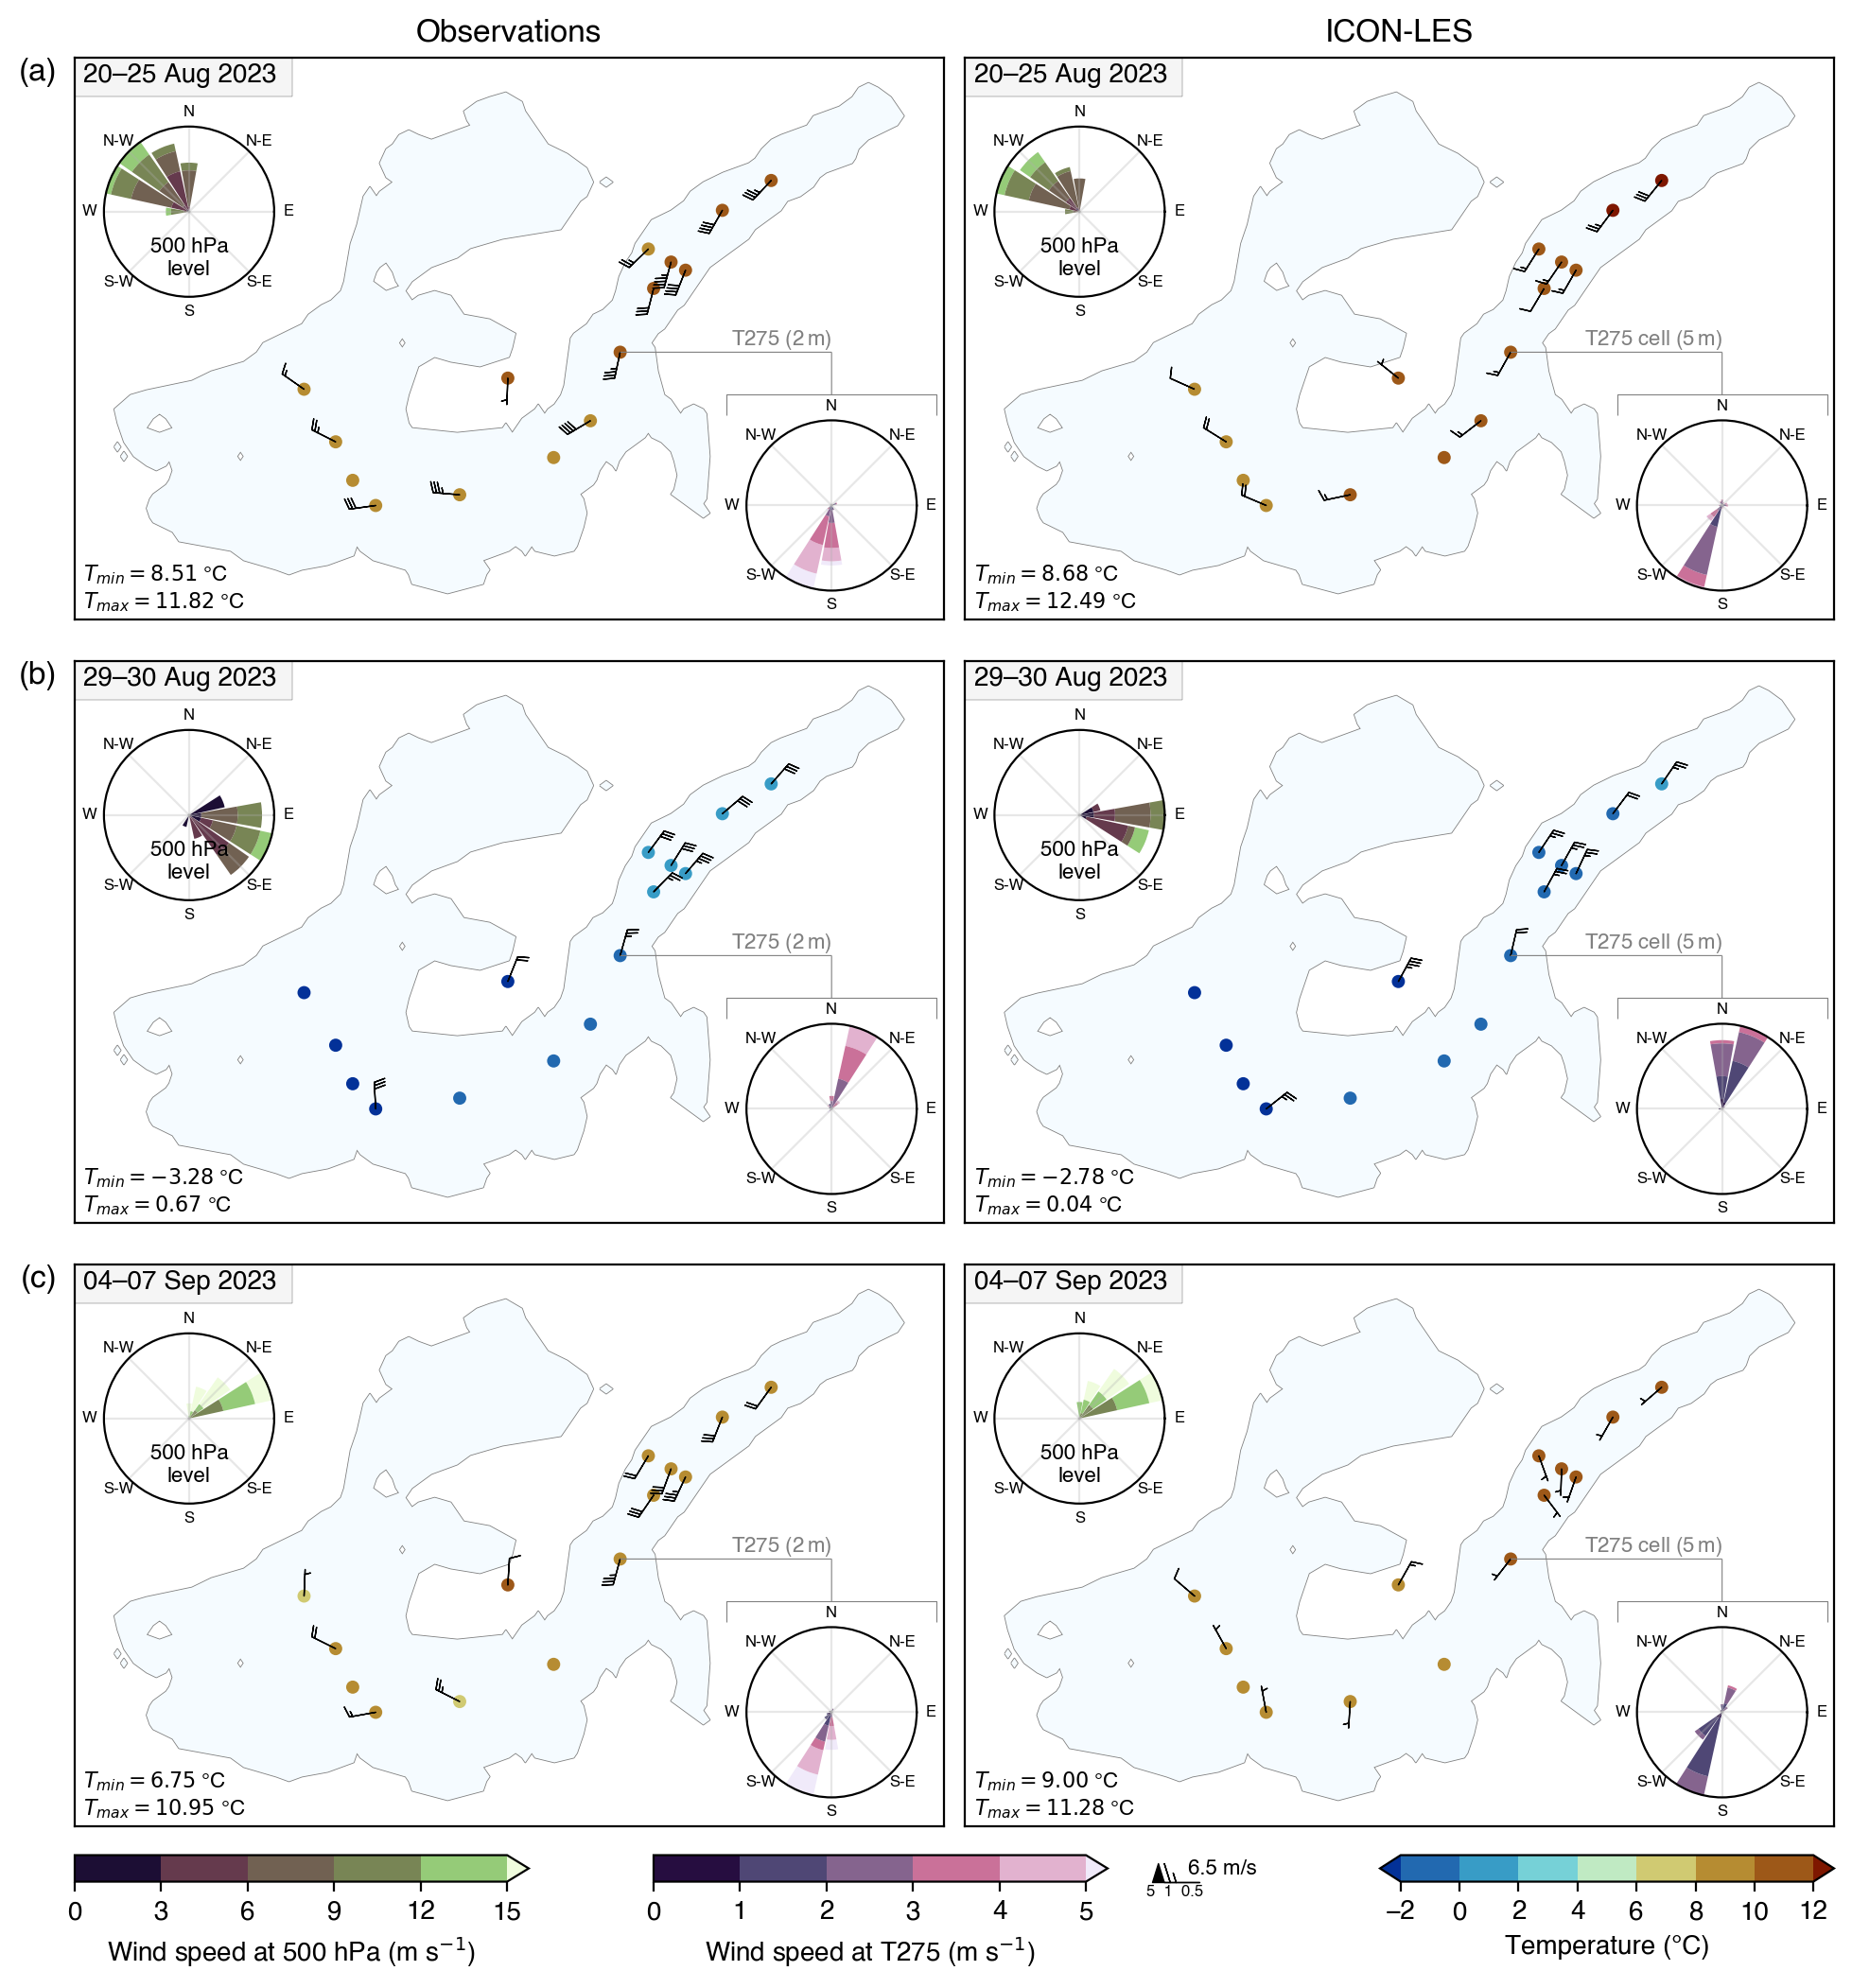

In [17]:
#bi = dict(half=2.57222, full=5.144, flag=25.7222)
# bi = dict(half=1, full=2, flag=10)
bi = dict(half=.5, full=1, flag=5)

# create axis for main panels
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(12,14), sharex=True, sharey=True, dpi=200,
                        gridspec_kw={'hspace': -0.275, 'wspace': 0.025})

# create axis for colorbars
cax1 = fig.add_axes([0.125, 0.14, 0.2, 0.01])   # 500 hPa windrose
cax2a = fig.add_axes([0.38, 0.14, 0.2, 0.01])   # station windrose
cax2b = fig.add_axes([0.59, 0.13, 0.04, 0.02])  # wind barb legend
cax3 = fig.add_axes([0.70, 0.14, 0.2, 0.01])    # temperature

# base map with glacier
for ax in axs.flatten():
    rgi_hef.boundary.plot(ax=ax, lw=.6, color='grey', zorder=-10)
    rgi_hef.plot(ax=ax, color='#f5fbff',alpha=1)

# plot panels for defined timeframes (incl. temperature, wind barbs and windroses)
cmap, norm, sm = get_discrete_cmap(cm.roma_r, range(-2,13,2), 'both') # -> needed during plotting routine
fig.colorbar(sm, cax=cax3, orientation="horizontal", label='Temperature (°C)')

plot_maps(axs[0][0], axs[0][1], '2023-08-20', '2023-08-25')
plot_maps(axs[1][0], axs[1][1], '2023-08-29', '2023-08-30')
plot_maps(axs[2][0], axs[2][1], '2023-09-04', '2023-09-07')

# add column titles
axs[0][0].set_title('Observations')
axs[0][1].set_title('ICON-LES')

# remove tick labels
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])


# build discrete colormaps for windroses
_,_,sm = get_discrete_cmap(cm.tokyo, np.arange(0,16,3), extend='max')
fig.colorbar(sm, cax=cax1, orientation="horizontal", label='Wind speed at 500 hPa (m s$^{-1}$)', extend="max")

_,_,sm = get_discrete_cmap(cm.acton, np.arange(0,6,1), extend='max')
fig.colorbar(sm, cax=cax2a, orientation="horizontal", label='Wind speed at T275 (m s$^{-1}$)', extend="max")

# wind barb legend
cax2b.barbs(0,0, sum(bi.values()),0, barb_increments=bi, length=6, lw=.5, pivot='middle')
cax2b.text(0.015, 0.005, f'{sum(bi.values())} m/s', ha='left', va='bottom', fontsize=8)
cax2b.text(-0.035, -0.006, f'{bi["flag"]}  {bi["full"]}  {bi["half"]}', ha='left', va='top', fontsize=6)
cax2b.set_axis_off()

# panel letters 
for ax, letter in zip(axs[:, 0], string.ascii_lowercase):
    ax.text(
        -0.02, 1, f'({letter})',
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        va='top', ha='right'
    )

# save and show
plt.savefig(fig_png_dir + f'HEF_AWS_ICON_windmap_v2.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_AWS_ICON_windmap_v2.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()

In [13]:
t275_coords = df_loc[df_loc['loc']=='T275'].iloc[0].to_dict()

In [14]:
ds = xr.open_dataset('/Users/geoalxx/Python/glacier_space/data_obs_h2/ECMWF_ERA5_hourly_wind_500hPa__20230801_20230930.nc')

ds = ds.sel(lat=t275_coords['lat'],lon=t275_coords['lon'], method='nearest').isel(plev=0)

In [15]:
df = ds[['u','v']].to_dataframe()
df.index = pd.to_datetime(df.index, utc=True)
df = df[['u','v']]
df['ws'] = wind_speed(df.u.values * units('m/s'), df.v.values * units('m/s'))
df['wd'] = wind_direction(df.u.values * units('m/s'), df.v.values * units('m/s'))
df_wind_era5_500 = df.copy()


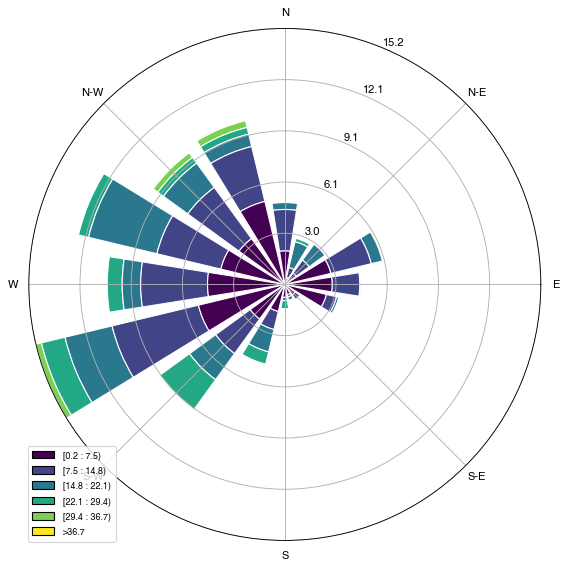

In [72]:
from windrose import WindroseAxes

ax = WindroseAxes.from_ax()
ax.bar(df['wd'], df['ws'], normed=True, opening=0.8, edgecolor="white")
ax.set_legend()